# Chapter 1 — Engineering Accountability
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 1 — Engineering Accountability.

When a structure fails, the question that follows is almost never "what broke?" The question is "who knew what, and when?" Structural failure is rarely a surprise to the physics — the crack was growing, the connection was overloaded, the fatigue life was being consumed — but it is often a surprise to the engineers because they were not measuring. This chapter places strain measurement in its most fundamental context: not as a technical exercise but as an act of professional responsibility.

The history of structural failure is partly a history of measurement gaps. The Tacoma Narrows Bridge collapsed in 1940 because aeroelastic flutter was not a recognized design load: its oscillations had been watched, surveyed, and filmed for months, but the torsional mode that destroyed it was neither measured nor understood. The Hyatt Regency walkways fell in 1981 because a design change doubled the load on a critical connection with no load verification or field measurement. Aloha Airlines Flight 243 peeled its fuselage at altitude in 1988 despite service bulletins and maintenance records that documented exactly the failure mode that occurred.

The cost asymmetry between measuring and not measuring is severe, and it can be shown with published numbers rather than asserted. This notebook does that with two figures: a log-scale cost ledger for a single documented failure — the I-35W bridge in Minneapolis, where the monitoring hardware and the failure consequences both carry citable price tags — and a failure timeline that categorizes each event by the type of measurement gap that allowed it.

**This notebook demonstrates:**
1. The I-35W cost ledger — documented monitoring cost against documented failure cost, on a log scale, every value sourced
2. Structural failure timeline (1940–2007) — each event classified as measurement absent, insufficient, or ignored

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures for this chapter are written here; the book includes these exact files.
OUT_DIR = Path("../src/media/ch01")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — What Measurement Costs, and What Failure Costs: I-35W

The case for measuring is partly an economic one, and it is worth making with real money rather than with invented units. The I-35W Mississippi River bridge in Minneapolis, which collapsed during the evening rush hour on 1 August 2007, killing 13 people and injuring 145, is the rare failure where both sides of the ledger were later priced in public documents.

On the measurement side, the FHWA published per-channel costs for remote data-acquisition systems, and one of the two sites it benchmarked was the I-35W replacement bridge itself: about **\$170 per channel** for loggers, cellular modems, enclosures, and power supplies (Collins et al., 2014, p. 89). On the failure side, three quantities were established by the state, the courts, and MnDOT: the detour's drag on the Minnesota economy, the compensation paid to the victims, and the cost of the replacement span.

A caution about what this comparison does and does not claim. The NTSB found the probable cause to be a design error — the U10 gusset plates were about 1/2 in (13 mm) thick where roughly 1 in (25 mm) was required — aggravated by decades of added dead load and by construction materials staged on the deck that day. Instrumentation would not have corrected a 1965 calculation. What it would have done is make the resulting overstress *observable*: those plates were never load-rated and never measured, which is why the NTSB's leading recommendation after the investigation was that gusset plates be included in bridge load ratings. The figure below compares magnitudes. It is not a claim that a strain gage would have held the bridge up.

The logarithmic axis is a necessity, not a style choice. One monitoring channel and one replacement bridge differ by roughly six orders of magnitude, and no linear axis can show both.

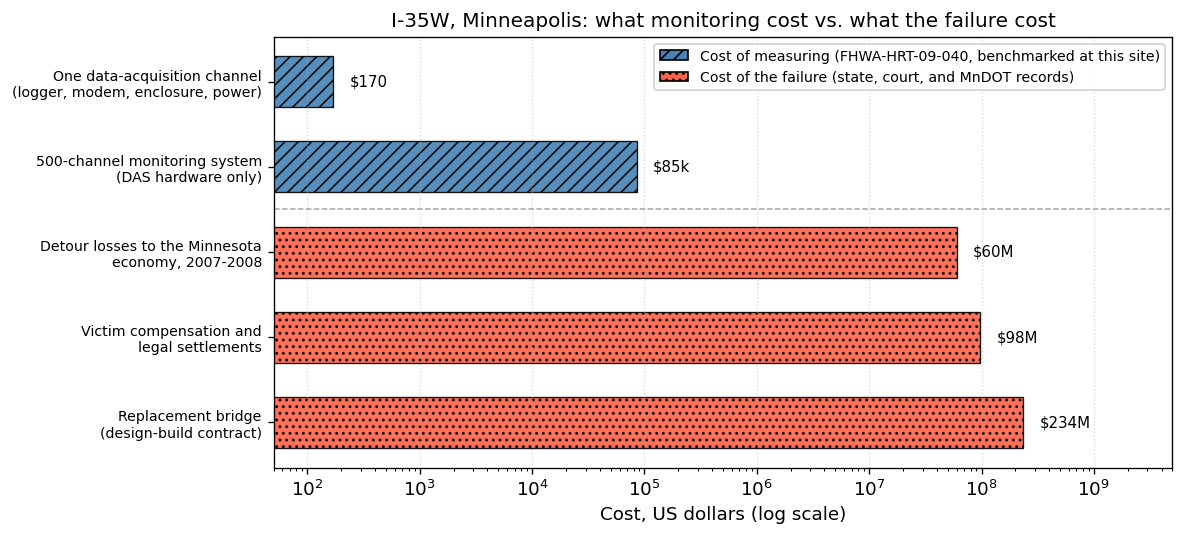

Documented failure costs plotted:  $392M
500-channel DAS hardware:          $85k
Ratio:                             4,611 : 1
Ratio if a fully installed system costs 10x the hardware: 461 : 1


In [2]:
# Figure 1.1 — the I-35W cost ledger. Every value below is a published figure;
# the sources are tabulated in the markdown cell that follows.
#
# Nominal US dollars, not inflation-adjusted: the failure costs are 2007-2012
# dollars and the per-channel hardware cost is a 2014 report on equipment of the
# same era, so they sit on one axis without correction.

# (label, amount in USD, side of the ledger)
LEDGER = [
    ("One data-acquisition channel\n(logger, modem, enclosure, power)", 170,         "measure"),
    ("500-channel monitoring system\n(DAS hardware only)",              500 * 170,   "measure"),
    ("Detour losses to the Minnesota\neconomy, 2007-2008",              60_000_000,  "failure"),
    ("Victim compensation and\nlegal settlements",                      97_940_000,  "failure"),
    ("Replacement bridge\n(design-build contract)",                     234_000_000, "failure"),
]

# The softcover edition prints in black, so each side of the ledger carries a
# hatch as well as a color — the figure has to read with the color removed.
COLOR_MEASURE = 'steelblue'
COLOR_FAILURE = 'tomato'
HATCH_MEASURE = '///'
HATCH_FAILURE = '...'

labels  = [row[0] for row in LEDGER]
amounts = np.array([row[1] for row in LEDGER], dtype=float)
colors  = [COLOR_MEASURE if row[2] == "measure" else COLOR_FAILURE for row in LEDGER]
hatches = [HATCH_MEASURE if row[2] == "measure" else HATCH_FAILURE for row in LEDGER]


def usd(value):
    """Format a dollar amount at the precision the source documents report."""
    if value >= 1e6:
        return f"${value / 1e6:,.0f}M"
    if value >= 1e3:
        return f"${value / 1e3:,.0f}k"
    return f"${value:,.0f}"


y = np.arange(len(LEDGER))[::-1]          # first row at the top
fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.barh(y, amounts, height=0.6, color=colors, alpha=0.9,
               edgecolor='black', linewidth=0.8)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
ax.set_xscale('log')
ax.set_xlim(50, 5e9)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel('Cost, US dollars (log scale)')
ax.set_title('I-35W, Minneapolis: what monitoring cost vs. what the failure cost')
ax.grid(True, axis='x', linestyle=':', alpha=0.5)

# Rule between the two sides of the ledger, so the grouping survives in gray.
n_measure = sum(1 for row in LEDGER if row[2] == "measure")
ax.axhline(len(LEDGER) - n_measure - 0.5, color='gray', lw=0.9, linestyle='--', alpha=0.7)

for yi, amount in zip(y, amounts):
    ax.text(amount * 1.4, yi, usd(amount), va='center', ha='left', fontsize=9)

legend_handles = [
    mpatches.Patch(facecolor=COLOR_MEASURE, edgecolor='black', hatch=HATCH_MEASURE,
                   label='Cost of measuring (FHWA-HRT-09-040, benchmarked at this site)'),
    mpatches.Patch(facecolor=COLOR_FAILURE, edgecolor='black', hatch=HATCH_FAILURE,
                   label='Cost of the failure (state, court, and MnDOT records)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_nb1_cost_vs_failure.png', bbox_inches='tight', dpi=150)
plt.show()

failure_total = amounts[2:].sum()
system_cost = amounts[1]
print(f"Documented failure costs plotted:  {usd(failure_total)}")
print(f"500-channel DAS hardware:          {usd(system_cost)}")
print(f"Ratio:                             {failure_total / system_cost:,.0f} : 1")
print(f"Ratio if a fully installed system costs 10x the hardware: "
      f"{failure_total / (10 * system_cost):,.0f} : 1")

### Figure 1.1 — sources and caveats

| Quantity | Value | Source |
|---|---|---|
| Remote DAS hardware, per channel, benchmarked at the I-35W replacement site | \$170 (\$160 at the Florida companion site) | Collins, J., Mullins, G., Lewis, C., and Winters, D. (2014). *State of the Practice and Art for Structural Health Monitoring of Bridge Substructures*. Report FHWA-HRT-09-040, Federal Highway Administration, Turner-Fairbank Highway Research Center, p. 89. |
| Net loss to the Minnesota economy from the detour | \$17M (2007) + \$43M (2008) = \$60M | Minnesota DEED and Mn/DOT. *Economic Impacts of the I-35W Bridge Collapse*. Road-user cost was separately put at \$400,000/day; the \$113,000/day net figure used here is the state's economic-output estimate. |
| Victim compensation fund | \$36.64M paid to 179 claimants, from a \$38M appropriation | Laws of Minnesota 2008, ch. 288; Minn. Stat. § 3.7394. |
| URS Corporation settlement | \$52.4M | Settled 2010. URS had been retained to evaluate the bridge before the collapse. |
| Jacobs Engineering settlement | \$8.9M | Settled 2012. Jacobs was successor to Sverdrup & Parcel, the original designer. |
| Replacement bridge | \$234M | MnDOT design-build contract awarded to Flatiron–Manson, 19 September 2007. |
| Probable cause and the load-rating gap | U10 gusset plates ≈ 1/2 in where ≈ 1 in was required | NTSB. (2008). *Collapse of I-35W Highway Bridge, Minneapolis, Minnesota, August 1, 2007*. Report HAR-08/03. |

**Caveats, stated plainly.**

1. **The measurement bars are hardware only.** The \$170/channel figure covers loggers, cellular modems, enclosures, and power supplies. It excludes the sensors themselves, cabling, installation labor, and cellular service contracts. A fully installed system costs several times more — the last line the cell prints shows that the argument survives a 10× correction with room to spare.
2. **The failure bars are incomplete in the other direction.** Emergency response, the recovery operation, MnDOT's detour improvements, the federal investigation, and the nationwide gusset-plate re-rating that followed are all excluded. The true failure cost is higher than what is plotted.
3. **Nominal dollars.** Nothing here is inflation-adjusted. Across 2007–2014 that correction is small next to a log axis spanning six decades.
4. **One case is not a law.** These are the numbers for one bridge, chosen because both halves of its ledger are public. Another structure would produce different magnitudes. The *asymmetry* is the transferable part, not the particular ratio.

---
## 2 — Structural Failure Timeline: Absent, Insufficient, Ignored

Every significant structural failure has a measurement dimension. Some failed because no monitoring system existed for the relevant failure mode (*absent*). Some failed because monitoring existed but used the wrong method, scope, or frequency (*insufficient*). Some failed despite data or warning signs that existed in engineering records but did not prompt corrective action (*ignored*). The distinction matters because each category implies a different engineering response.

"Absent" failures dominated the early decades of structural engineering, when sensing technologies were expensive or unavailable and the relevant failure modes were not yet understood. "Insufficient" failures became more common as monitoring spread but before best practices for scope, frequency, and method selection were established. "Ignored" failures represent an organizational failure rather than a technical one — the data existed, and the response did not occur. Different root causes require different corrective actions: absent calls for instrumentation, insufficient calls for better design of the monitoring program, ignored calls for organizational change.

The seven events shown span 1940 to 2007 and cover bridge, aviation, and building failures. They were chosen for the clarity of their measurement gap, not as a comprehensive survey. The detailed source table in the cell below documents the primary references and the basis for each classification so that the categorization can be independently verified.

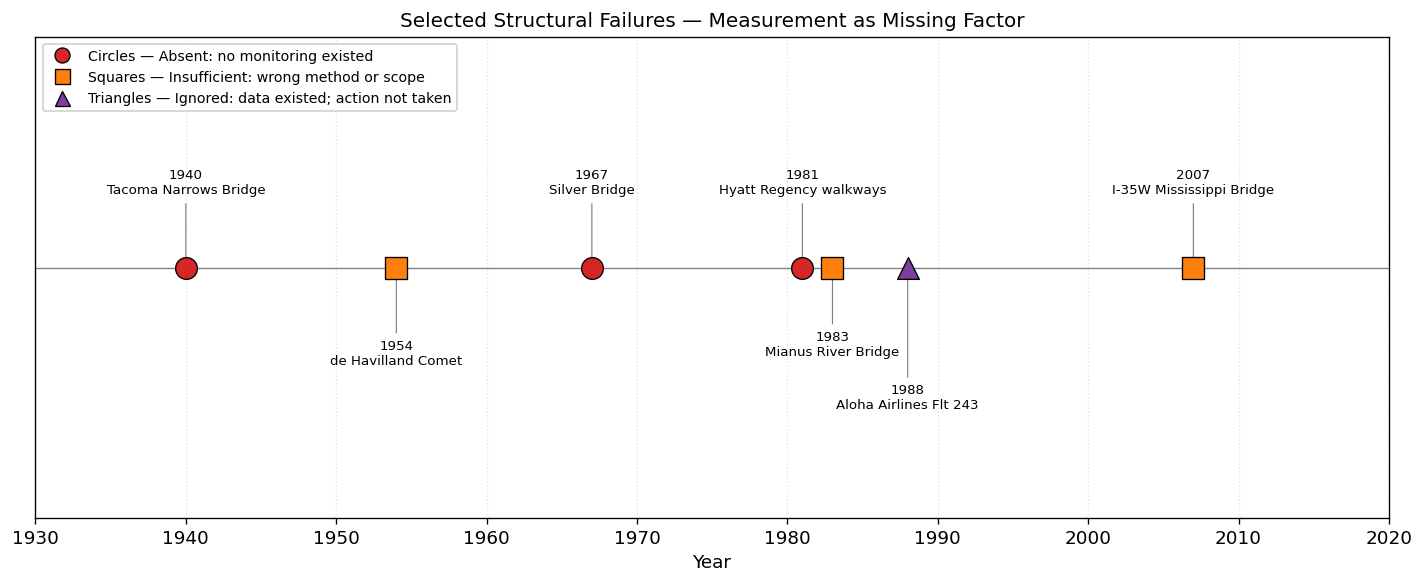

In [3]:
from matplotlib.lines import Line2D

# Category definitions:
#   Absent      — no measurement or monitoring system existed for the relevant failure mode
#   Insufficient — measurement existed but was wrong scope, wrong method, or too infrequent
#   Ignored     — data or warning signs existed; corrective action was not taken
#
# Each category gets its own marker shape as well as its own color, so the
# timeline still reads in the black-and-white softcover edition.

CATEGORY_COLORS = {
    "Absent":       "#d62728",
    "Insufficient": "#ff7f0e",
    "Ignored":      "#7b3f9e",
}

CATEGORY_MARKERS = {
    "Absent":       "o",   # circle
    "Insufficient": "s",   # square
    "Ignored":      "^",   # triangle
}

# (year, short_label, category, y_text, va)
# y_text and va give per-event vertical stagger to prevent label collisions in the
# dense 1981–1988 cluster.  Timeline spans 1930–2020 at 12 inches wide.
events = [
    (1940, "Tacoma Narrows Bridge",    "Absent",       1.080, "bottom"),
    (1954, "de Havilland Comet",       "Insufficient", 0.920, "top"),
    (1967, "Silver Bridge",            "Absent",       1.080, "bottom"),
    (1981, "Hyatt Regency walkways",   "Absent",       1.080, "bottom"),  # above, clears 1988
    (1983, "Mianus River Bridge",      "Insufficient", 0.930, "top"),     # below level 1
    (1988, "Aloha Airlines Flt 243",   "Ignored",      0.870, "top"),     # below level 2
    (2007, "I-35W Mississippi Bridge", "Insufficient", 1.080, "bottom"),
]

fig, ax = plt.subplots(figsize=(12, 5.0))
ax.axhline(1, color='gray', lw=0.8, zorder=1)
ax.set_xlim(1930, 2020)
ax.set_ylim(0.72, 1.26)
ax.set_xlabel('Year')
ax.set_yticks([])
ax.set_title('Selected Structural Failures — Measurement as Missing Factor')
ax.grid(True, axis='x', linestyle=':', alpha=0.35)

for yr, name, cat, y_text, va in events:
    color = CATEGORY_COLORS[cat]
    marker = CATEGORY_MARKERS[cat]
    ax.scatter(yr, 1, s=170, color=color, marker=marker, zorder=5,
               edgecolors='black', linewidths=0.8)
    ax.annotate(
        f"{yr}\n{name}",
        xy=(yr, 1),
        xytext=(yr, y_text),
        ha='center', va=va, fontsize=8,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.7),
    )

# Legend names the shape as well as the category — the color is the secondary cue.
legend_specs = [
    ("Absent",       "Circles — Absent: no monitoring existed"),
    ("Insufficient", "Squares — Insufficient: wrong method or scope"),
    ("Ignored",      "Triangles — Ignored: data existed; action not taken"),
]
legend_handles = [
    Line2D([], [], linestyle='none', marker=CATEGORY_MARKERS[cat], markersize=9,
           markerfacecolor=CATEGORY_COLORS[cat], markeredgecolor='black',
           markeredgewidth=0.8, label=label)
    for cat, label in legend_specs
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_nb2_failure_timeline.png', bbox_inches='tight', dpi=150)
plt.show()


### Figure 1.2 — Event categorization and sources

Each failure is assigned to exactly one category. The criteria and primary sources are listed below so the classification can be checked independently.

---

**Absent** — no measurement or monitoring system existed for the relevant failure mode at the time of the incident.

| Event | Year | Basis for "Absent" | Primary source |
|---|---|---|---|
| Tacoma Narrows Bridge | 1940 | Aeroelastic flutter was not a recognized design load. The deck's vertical oscillations had been observed with a transit, targets, and motion-picture film for months, but the torsional flutter mode that destroyed the bridge was neither instrumented nor understood. | Farquharson, F.B. (1950). *Aerodynamic Stability of Suspension Bridges*. Univ. of Washington Bulletin 116 (5 parts). Federal Works Agency investigation. |
| Silver Bridge | 1967 | Stress-corrosion cracking of the eyebar chain was not a monitored failure mode; no in-service inspection protocol addressed internal corrosion of the pin–eyebar interface. | NTSB. (1971). *Collapse of U.S. 35 Highway Bridge, Point Pleasant, West Virginia, December 15, 1967*. Report NTSB-HRS-71-1. |
| Hyatt Regency walkways | 1981 | A contractor-initiated design change doubled the load on the fourth-floor box-beam rod connection; no load verification or field measurement was performed on the as-built assembly before occupancy. | Marshall, R.D., Pfrang, E.O., Leyendecker, E.V., Woodward, K.A., Reed, R.P., Kasen, M.B., and Shives, T.R. (1982). *Investigation of the Kansas City Hyatt Regency Walkways Collapse*. NBSIR 82-2465, National Bureau of Standards. DOI 10.6028/NBS.IR.82-2465A. |

---

**Insufficient** — some measurement or inspection existed, but used the wrong method, wrong scope, or insufficient frequency to detect the actual failure mode.

| Event | Year | Basis for "Insufficient" | Primary source |
|---|---|---|---|
| de Havilland Comet | 1954 | The fatigue test program immersed the cabin in water and applied pressure cycles, but the stress concentration at the square ADF window cutouts under repeated pressurization was not captured by this method; the test specimen had also accumulated prior flight cycles that reduced its residual life. | HMSO. (1955). *Report of the Court of Inquiry into the Accidents to Comet Aircraft G-ALYP and G-ALYY* (Cohen Report). London: HMSO. |
| Mianus River Bridge | 1983 | Connecticut DOT conducted periodic visual inspections, but the pin-and-hanger assemblies were examined externally only; internal corrosion of the pins was inaccessible to visual methods and was not measured by any other means. | NTSB. (1984). *Collapse of a Suspended Span of Route 95 Highway Bridge over the Mianus River, Greenwich, Connecticut, June 28, 1983*. Report HAR-84/03. |
| I-35W Mississippi Bridge | 2007 | The bridge was inspected regularly and rated "structurally deficient" as early as 1990 and again in 2005, but those findings concerned fatigue cracking and corrosion elsewhere in the structure. The U10 gusset plates that NTSB identified as the critical undersized members had never been load-rated or measured, so the inspection program, however conscientious, was scoped to the wrong members. Construction equipment and materials adding significant dead load were staged on the deck on the day of collapse. | NTSB. (2008). *Collapse of I-35W Highway Bridge, Minneapolis, Minnesota, August 1, 2007*. Report HAR-08/03. |

---

**Ignored** — measurement data or documented warning signs existed in agency or operator records; corrective action of sufficient scope was not taken before failure.

| Event | Year | Basis for "Ignored" | Primary source |
|---|---|---|---|
| Aloha Airlines Flt 243 | 1988 | Boeing had issued service bulletins on lap-joint fatigue in the 737 airframe; Aloha's own maintenance records documented fuselage skin disbonding; the FAA-approved inspection interval was not updated to reflect the fleet's age and high cycle count. | NTSB. (1989). *Aircraft Accident Report: Aloha Airlines, Flight 243, Boeing 737-200*. Report AAR-89/03. |


---
## Where to take this next

This notebook is a starting point, not a finished analysis. A few concrete ways to build on it:

1. **Ground the cost figure in real dollars.** Replace the illustrative relative-cost units with published figures from a single documented case — for example, the settlement and reconstruction totals from the Hyatt Regency or I-35W investigations — and re-plot on the same log axis. Seeing where an actual project's instrumentation budget falls against its realized failure cost turns the qualitative argument into a quantitative one for your own domain.

2. **Extend the timeline into your own field.** Add failures from pressure vessels, wind turbines, offshore structures, or civil infrastructure you work with, and classify each as *absent*, *insufficient*, or *ignored*. Then compute the fraction of events in each category by decade to test whether the book's claimed shift — from unmeasured failure modes toward failures where data existed but was not heeded — holds in your data.

3. **Make the taxonomy reproducible.** Turn the classification into a small function that takes a structured event record (Was monitoring present? Was the right method used? Was the data acted on?) and returns the category. Encoding the decision rule this way forces every judgment to be explicit and lets a reviewer challenge a specific answer rather than the label as a whole.